# Using Ragas to Evaluate a RAG Application built with LangChain and LangGraph

In the following notebook, we'll be looking at how [Ragas](https://github.com/explodinggradients/ragas) can be helpful in a number of ways when looking to evaluate your RAG applications!

While this example is rooted in LangChain/LangGraph - Ragas is framework agnostic (you don't even need to be using a framework!).

- 🤝 Breakout Room #1
  1. Task 1: Installing Required Libraries
  2. Task 2: Set Environment Variables
  3. Task 3: Synthetic Dataset Generation for Evaluation using Ragas
  4. Task 4: Evaluating our Pipeline with Ragas
  5. Task 6: Making Adjustments and Re-Evaluating

But first! Let's set some dependencies!

## Dependencies and API Keys:

> NOTE: Please skip the pip install commands if you are running the notebook locally.

In [1]:
#!pip install -qU ragas==0.2.10

In [2]:
#!pip install -qU langchain-community==0.3.14 langchain-openai==0.2.14 unstructured==0.16.12 langgraph==0.2.61 langchain-qdrant==0.2.0

We'll also need to provide our API keys.

First, OpenAI's for our LLM/embedding model combination!

In [3]:
import os
from getpass import getpass
from dotenv import load_dotenv
load_dotenv()

def set_api_key_if_not_present(key_name, prompt_message):
    if key_name not in os.environ or not os.environ[key_name]:
        os.environ[key_name] = getpass.getpass(prompt_message)

In [4]:

os.environ["LANGCHAIN_TRACING_V2"] = "true"
set_api_key_if_not_present("LANGCHAIN_API_KEY", "LANGCHAIN_API_KEY:")
set_api_key_if_not_present("OPENAI_API_KEY","Please enter your OpenAI API key!")
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OPTIONALLY:

We can also provide a Ragas API key - which you can sign-up for [here](https://app.ragas.io/).

In [5]:
set_api_key_if_not_present("RAGAS_APP_TOKEN", "Please enter your Ragas API key!")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - and download our webpages which we'll be using for our data today.

These webpages are from [Simon Willison's](https://simonwillison.net/) yearly "AI learnings".

- [2023 Blog](https://simonwillison.net/2023/Dec/31/ai-in-2023/)
- [2024 Blog](https://simonwillison.net/2024/Dec/31/llms-in-2024/)

Let's start by collecting our data into a useful pile!

In [6]:
!mkdir data

/home/mbudisic/Applications/Cursor_9f43194406eb2579c899757921a907b9.AppImage: cannot create directory ‘data’: File exists


In [7]:
!curl https://simonwillison.net/2023/Dec/31/ai-in-2023/ -o data/2023_llms.html

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 31524    0 31524    0     0   206k      0 --:--:-- --:--:-- --:--:--  208k


In [8]:
!curl https://simonwillison.net/2024/Dec/31/llms-in-2024/ -o data/2024_llms.html

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 70691    0 70691    0     0   444k      0 --:--:-- --:--:-- --:--:--  442k


Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [9]:
from langchain_community.document_loaders import DirectoryLoader

path = "data/"
loader = DirectoryLoader(path, glob="*.html")
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [10]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano", seed=42)) # controlling seed for reproducibility
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

In [11]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset_template = generator.generate_with_langchain_docs(docs, testset_size=10)



Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/12 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/18 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [12]:
dataset_template.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,Google is like a big search thing right?,[The ethics of this space remain diabolically ...,The context mentions Google as one of the orga...,single_hop_specifc_query_synthesizer
1,What were the significant developments and ins...,[Simon Willison’s Weblog Subscribe Stuff we fi...,"According to Simon Willison’s Weblog, 2023 was...",single_hop_specifc_query_synthesizer
2,What is DALL-E 3 and how does it relate to AI ...,[the document includes some of the clearest ex...,The context provided does not include specific...,single_hop_specifc_query_synthesizer
3,What is Google’s contribution to the advanceme...,[Things we learned about LLMs in 2024 31st Dec...,Google’s Gemini 1.5 Pro introduced several new...,single_hop_specifc_query_synthesizer
4,"How do advancements in model capabilities, suc...",[<1-hop>\n\nThe ethics of this space remain di...,The recent progress in large language models (...,multi_hop_abstract_query_synthesizer
5,How do cost and resource considerations influe...,[<1-hop>\n\nThe ethics of this space remain di...,The context highlights that the training cost ...,multi_hop_abstract_query_synthesizer
6,How do the advancments in LLMs like llama 3.2 ...,[<1-hop>\n\npunch massively above their weight...,The advancements in LLMs such as running Llama...,multi_hop_abstract_query_synthesizer
7,How do evaluation frameworks and benchmarks fo...,[<1-hop>\n\nacknowledge that. If you tell me t...,The context highlights that writing effective ...,multi_hop_abstract_query_synthesizer
8,How do synthetic data and AI development chall...,[<1-hop>\n\nSimon Willison’s Weblog Subscribe ...,"In 2023, AI, particularly Large Language Model...",multi_hop_specific_query_synthesizer
9,How do the features of Llama 2 and Llama 3.2 9...,[<1-hop>\n\nthe document includes some of the ...,The context highlights that Llama 2 and Llama ...,multi_hop_specific_query_synthesizer


#### OPTIONAL:

If you've provided your Ragas API key - you can use this web interface to look at the created data!

In [13]:
dataset_template.upload()

Testset uploaded! View at https://app.ragas.io/dashboard/alignment/testset/438f9219-513a-4162-a0d7-7c18d2bbc09f


'https://app.ragas.io/dashboard/alignment/testset/438f9219-513a-4162-a0d7-7c18d2bbc09f'

## LangChain RAG

Now we'll construct our LangChain RAG, which we will be evaluating using the above created test data!

### R - Retrieval

Let's start with building our retrieval pipeline, which will involve loading the same data we used to create our synthetic test set above.

> NOTE: We need to use the same data - as our test set is specifically designed for this data.

In [14]:
path = "data/"
loader = DirectoryLoader(path, glob="*.html")
docs = loader.load()

Now that we have our data loaded, let's split it into chunks!

In [15]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

75

#### ❓ Question: 

What is the purpose of the `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter`?


#### ❗ Answer:

The `chunk_overlap` ensures that each character in the query exists 
contiguously with surrounding material in at least one document that can be retrieved.
This is needed because tokenization and chunking do not operate over the same 
units (tokens vs. characters) so it can happen that a chunk ends up dividing a piece of text 
compromising its tokenization. More broadly, even if we were to split at whitespace (respecting tokenization)
we may still want a non-zero chunk overlap just so that entire semantic units (e.g. sentences)
are more likely to land in at least one contiguous document which, when retrieved,
gives a complete information to LLM via in-context learning.

Next up, we'll need to provide an embedding model that we can use to construct our vector store.

In [16]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can build our in memory QDrant vector store.

In [17]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="ai_across_years",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="ai_across_years",
    embedding=embeddings,
)

We can now add our documents to our vector store.

In [18]:
_ = vector_store.add_documents(documents=split_documents)

Let's define our retriever.

In [19]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

Now we can produce a node for retrieval!

In [20]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

### Augmented

Let's create a simple RAG prompt!

In [21]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

We'll also need an LLM to generate responses - we'll use `gpt-4o-mini` to avoid using the same model as our judge model.

In [22]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini", seed=42)

Then we can create a `generate` node!

In [23]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

### Building RAG Graph with LangGraph

Let's create some state for our LangGraph RAG graph!

In [24]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

Now we can build our simple graph!

> NOTE: We're using `add_sequence` since we will always move from retrieval to generation. This is essentially building a chain in LangGraph.

In [25]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

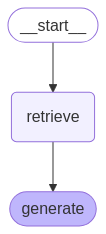

In [26]:
graph


Let's do a test to make sure it's doing what we'd expect.

In [27]:
response = graph.invoke({"question" : "How are LLM agents useful?"})

In [28]:
response["response"]

'LLM agents are useful primarily because they can act on your behalf by accessing and running tools in a loop to solve problems, somewhat like a travel agent model. They enable automation of tasks by making decisions and performing actions based on language inputs.\n\nThey are relatively easy to build, requiring only a few hundred lines of code if the right training data is available, making them accessible beyond just the super-rich or large corporations.\n\nAdditionally, LLM agents can generate code and improve it iteratively by running the code, checking for errors, and rewriting it, which reduces the impact of their tendency to hallucinate false information—at least in code generation.\n\nHowever, their utility is still debated due to challenges like gullibility (tendency to believe false information), reliability, and ethical concerns. Despite these issues, they hold promise for automating complex tasks and assisting users effectively when integrated with appropriate tools and ove

## Evaluating the App with Ragas

Now we can finally do our evaluation!

We'll start by running the queries we generated usign SDG above through our application to get context and responses.

In [29]:
import copy
dataset1 = copy.deepcopy(dataset_template)


for test_row in dataset1:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [30]:
dataset1.to_pandas()

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,Google is like a big search thing right?,[Just the other day Google Search was caught s...,[The ethics of this space remain diabolically ...,"Yes, Google Search is a large search engine th...",The context mentions Google as one of the orga...,single_hop_specifc_query_synthesizer
1,What were the significant developments and ins...,[Simon Willison’s Weblog\n\nSubscribe\n\nStuff...,[Simon Willison’s Weblog Subscribe Stuff we fi...,"According to Simon Willison’s Weblog, the year...","According to Simon Willison’s Weblog, 2023 was...",single_hop_specifc_query_synthesizer
2,What is DALL-E 3 and how does it relate to AI ...,[The biggest innovation here is that it opens ...,[the document includes some of the clearest ex...,The provided context does not mention DALL-E 3...,The context provided does not include specific...,single_hop_specifc_query_synthesizer
3,What is Google’s contribution to the advanceme...,[So training an LLM still isn’t something a ho...,[Things we learned about LLMs in 2024 31st Dec...,Google’s contribution to the advancements in L...,Google’s Gemini 1.5 Pro introduced several new...,single_hop_specifc_query_synthesizer
4,"How do advancements in model capabilities, suc...",[In October I upgraded my LLM CLI tool to supp...,[<1-hop>\n\nThe ethics of this space remain di...,"Advancements in model capabilities, such as in...",The recent progress in large language models (...,multi_hop_abstract_query_synthesizer
5,How do cost and resource considerations influe...,"[If you can gather the right data, and afford ...",[<1-hop>\n\nThe ethics of this space remain di...,Cost and resource considerations have a signif...,The context highlights that the training cost ...,multi_hop_abstract_query_synthesizer
6,How do the advancments in LLMs like llama 3.2 ...,[So training an LLM still isn’t something a ho...,[<1-hop>\n\npunch massively above their weight...,"Advancements in LLMs like Meta’s Llama 3.2, pa...",The advancements in LLMs such as running Llama...,multi_hop_abstract_query_synthesizer
7,How do evaluation frameworks and benchmarks fo...,[The two main categories I see are people who ...,[<1-hop>\n\nacknowledge that. If you tell me t...,Evaluation frameworks and benchmarks for large...,The context highlights that writing effective ...,multi_hop_abstract_query_synthesizer
8,How do synthetic data and AI development chall...,[Law is not ethics. Is it OK to train models o...,[<1-hop>\n\nSimon Willison’s Weblog Subscribe ...,The evolving role of AI in 2023 is illustrated...,"In 2023, AI, particularly Large Language Model...",multi_hop_specific_query_synthesizer
9,How do the features of Llama 2 and Llama 3.2 9...,[In October I upgraded my LLM CLI tool to supp...,[<1-hop>\n\nthe document includes some of the ...,The features of Meta’s Llama 2 and Llama 3.2 9...,The context highlights that Llama 2 and Llama ...,multi_hop_specific_query_synthesizer


Then we can convert that table into a `EvaluationDataset` which will make the process of evaluation smoother.

In [31]:
from ragas import EvaluationDataset

evaluation_dataset1 = EvaluationDataset.from_pandas(dataset1.to_pandas())

We'll need to select a judge model - in this case we're using the same model that was used to generate our Synthetic Data.

In [32]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano", seed=42))

Next up - we simply evaluate on our desired metrics!

In [33]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

result1 = evaluate(
    dataset=evaluation_dataset1,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config,
    experiment_name = "RAG1"
    )


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Exception raised in Job[43]: OutputParserException(Invalid json output: Evaluation frameworks and benchmarks for large language models (LLMs) are fundamentally connected to the concept of autonomy in artificial intelligence (AI). They are especially relevant when considering challenges such as gullibility and system reliability. The term "autonomy" in AI is often used without a precise, universally accepted definition. Generally, autonomy implies that an AI system can operate independently to achieve specific goals. An autonomous AI system can be likened to an agent that acts on behalf of a user or an LLM that uses tools iteratively to solve problems. Currently, large language models do not possess the robust decision-making capabilities necessary for truly autonomous behavior. Gullibility in LLMs refers to their tendency to believe information without verification. This gullibility undermines their ability to make trustworthy and meaningful decisions. If an autonomous agent cannot rel

## Making Adjustments and Re-Evaluating

Now that we've got our baseline - let's make a change and see how the model improves or doesn't improve!

> NOTE: This will be using Cohere's Rerank model (which was updated fairly [recently](https://docs.cohere.com/v2/changelog/rerank-v3.5)) - please be sure to [sign-up for an API key!](https://docs.cohere.com/reference/about)

In [34]:
set_api_key_if_not_present("COHERE_API_KEY", "Please enter your Cohere API key!")

In [35]:
#!pip install -qU cohere langchain_cohere


We'll first set our retriever to return more documents, which will allow us to take advantage of the reranking.

In [36]:
retriever = vector_store.as_retriever(search_kwargs={"k": 20})

Reranking, or contextual compression, is a technique that uses a reranker to compress the retrieved documents into a smaller set of documents.

This is essentially a slower, more accurate form of semantic similarity that we use on a smaller subset of our documents.

In [37]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

We can simply rebuild our graph with the new retriever!

In [38]:
class State(TypedDict):
  question: str
  context: List[Document]
  response: str

graph_builder = StateGraph(State).add_sequence([retrieve_adjusted, generate])
graph_builder.add_edge(START, "retrieve_adjusted")
graph = graph_builder.compile()

In [39]:
response = graph.invoke({"question" : "How are LLM agents useful?"})
response["response"]

"LLM agents are useful primarily as AI systems that can perform tasks by acting on a user's behalf, often by accessing and using various tools in a loop to solve problems. One of the clearest practical applications of LLMs is in writing code, where they excel due to the relatively simpler grammar rules of programming languages compared to natural languages. However, their broader utility as autonomous agents is currently limited by significant challenges, particularly their gullibility—they tend to believe anything they are told, which undermines their ability to make reliable decisions or distinguish truth from fiction. This limitation makes fully autonomous AI agents that reliably act on behalf of users still a work in progress, and some believe that overcoming this issue may require achieving artificial general intelligence (AGI). Despite these challenges, LLMs are useful tools when applied carefully and critically, especially in areas like coding where their strengths can be effect

In [40]:
import time
dataset2 = copy.deepcopy(dataset_template)
for test_row in dataset2:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(1)


In [41]:
evaluation_dataset2 = EvaluationDataset.from_pandas(dataset2.to_pandas())

In [42]:
result2 = evaluate(
    dataset=evaluation_dataset2,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config,
    experiment_name = "RAG2"
)


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

#### ❓ Question: 

Which system performed better, on what metrics, and why?



In [43]:
import pandas as pd
dfs = []
for label, r in zip(["First", "Second"], [result1, result2]):
    df = r.to_pandas().select_dtypes(include='number').mean().to_frame().T
    df.index = [label]  # assign custom index label
    dfs.append(df)

# Concatenate along rows
out = pd.concat(dfs, axis=0)
out



,context_recall,faithfulness,factual_correctness(mode=f1),answer_relevancy,context_entity_recall,noise_sensitivity(mode=relevant)
First,0.983333,0.967532,0.760,0.759074,0.313690,0.097219
Second,0.916667,0.983333,0.635,0.915022,0.412847,0.110472


#### ❗ Answer:

It appears that the main benefit of adding a reranker (second system) is 
in `answer_relevancy` and `context_entity_recall` metrics.

On the face of it, this makes sense. The job of the reranker is to evaluate
more pieces of context (20) by going beyond embedding distance, rather using
a reasoning model to provide a more nuanced similarity ranking between the
query and the documents. Taking top 5 documents in this way should 
provide a better overlap between the context and reference (ground truth), measured by
`context_entity_recall` and consequently `answer_relevancy`, which measures
the quality of the answer in reference to the query. 

Now, `factual_correctness` went down - I am likely not digging deep enough to 
fully understand why. But reading the docs, factual correctness relies on an
LLM breaking down the response and the reference into informational units ("claims")
and calculating the $F_1$ score:

$ \frac{2 \cdot (\text{claims in reference AND response})}{2 \cdot (\text{claims in reference AND response}) + (\text{claims only in reference}) + (\text{claims only in response})} $

So, if the reranker creates a context that is richer in information, it is 
plausible that the LLM in the second RAG can generate more 
"claims" than in the first RAG. As the reference does not change,
this will inflate the $\text{claims only in response}$ component of the 
denominator and bring down the `factual_correctness`.

To fully investigate this, one would have to compute precision ($F_0$) and 
recall ($F_\infty$) scores. I did not do this.

A second issue that clouds the judgement is the small number of queries (10)
that makes it hard to say if the variation in the mean score in so few queries
is enough to explain the difference.

One could run a more robust experiment that would cost more money (as Mike Dean did)
but I did a poor-man's version below, by estimating the variance in each score
by a jackknife calculation.


In [46]:
import numpy as np

def jackknife_mean_std(x):
    x = np.asarray(x)
    n = len(x)
    leave_one_out_means = np.array([
        np.nanmean(np.delete(x, i)) for i in range(n)
    ])
    mean_jack = np.nanmean(leave_one_out_means)
    var_jack = (n - 1) / n * np.sum((leave_one_out_means - mean_jack)**2)
    return np.sqrt(var_jack)



In [47]:
stds = out.copy()
stds[:] = np.nan
for (r, data) in zip(stds.index, [result1, result2]):
    for c in out.columns:
        stds.loc[r, c] = jackknife_mean_std([ res[c] for res in data.scores])

stds

,context_recall,faithfulness,factual_correctness(mode=f1),answer_relevancy,context_entity_recall,noise_sensitivity(mode=relevant)
First,0.016667,0.032603,0.080604,0.102520,0.100482,0.039739
Second,0.083333,0.016667,0.091000,0.007537,0.078739,0.034880


In [48]:
df_combined = pd.concat(
    [out, stds],
    axis=1,
    keys=["mean", "std"]
).swaplevel(axis=1).sort_index(axis=1)

df_combined

answer_relevancy           context_entity_recall            \
                   mean       std                  mean       std   
First          0.759074  0.102520              0.313690  0.100482   
Second         0.915022  0.007537              0.412847  0.078739   

       context_recall           factual_correctness(mode=f1)            \
                 mean       std                         mean       std   
First        0.983333  0.016667                        0.760  0.080604   
Second       0.916667  0.083333                        0.635  0.091000   

       faithfulness           noise_sensitivity(mode=relevant)            
               mean       std                             mean       std  
First      0.967532  0.032603                         0.097219  0.039739  
Second     0.983333  0.016667                         0.110472  0.034880

Then I evaluated the z-test, which should tell us
if the distribution of scores (for each category) means that First vs. Second are 
really drawn from different underlying distributions, or are they just "unlucky"
draws from the same distribution.

In [49]:
import numpy as np
from scipy.stats import norm

def z_test(mu1, mu2, se1, se2):
    z = (mu2 - mu1) / np.sqrt(se1**2 + se2**2)
    p = 2 * norm.sf(abs(z))
    return z, p

stats_df = pd.DataFrame(columns=['z_score', 'p_value'])
# The error occurs because df_combined has a MultiIndex with levels swapped
# We need to access the data differently - the structure is (metric, stat) not (stat, metric)
for c in df_combined.columns.get_level_values(0).unique():
    z, p = z_test(df_combined.loc['First', (c, 'mean')], 
                  df_combined.loc['Second', (c, 'mean')], 
                  df_combined.loc['First', (c, 'std')], 
                  df_combined.loc['Second', (c, 'std')])
    stats_df.loc[c] = [z, p]

stats_df

,z_score,p_value
answer_relevancy,1.517047,0.129255
context_entity_recall,0.776741,0.437312
context_recall,-0.784465,0.432768
factual_correctness(mode=f1),-1.028257,0.303829
faithfulness,0.431534,0.666080
noise_sensitivity(mode=relevant),0.250634,0.802097


Small p values would indicate that the difference between the First and Second
RAG is significant in a particular component. (Small would be say... less that 0.05).

Now, if I dotted my i-s and crossed my t-s, I'd go and check that the
assumptions for the test were valid (likely not) so I wouldn't want to claim
that there is numerical significance to the p-values. But we could 
likely assess the relative significance:

Differences in `answer_relevancy` (where we saw an improvement) are likely more significant, followed by
`factual_correctness` (where we saw the discussed drop).

`context_entity_recall` is in the middle of the pack.

There is likely no difference in `faithfulness` and `noise_sensitivity`.



**Conclusion** - this is presumably good news, as `answer_relevancy` is probably what we care the most.